# 01 — EDA

Eksplorasi dataset MBG sebelum modeling.

In [1]:
import re, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path
warnings.filterwarnings('ignore')

DATA_DIR = Path('../data')
LABEL_ORDER = [
    'Anggaran', 'Distribusi', 'Ekonomi', 'Kualitas Pangan',
    'Lainnya', 'Politik', 'Sasaran Penerima', 'Tata Kelola',
]

In [2]:
labeled    = pd.read_excel(DATA_DIR / 'raw/case_1_labeled_data.xlsx')
to_predict = pd.read_excel(DATA_DIR / 'raw/case_1_text_to_predict.xlsx')

for df in [labeled, to_predict]:
    df.columns = [c.strip().lower() for c in df.columns]

labeled['label'] = labeled['label'].astype(str).str.strip()

print(f'Labeled    : {labeled.shape}')
print(f'To predict : {to_predict.shape}')
labeled.head(3)

Labeled    : (5000, 2)
To predict : (1500, 2)


,full_text,label
0,@ARSIPAJA Pret. Di sekolah gw dapet MBG tetep ...,Sasaran Penerima
1,MBG bentuk penggarongan duit negara secara TSM...,Politik
2,@inzhapt_76 @ARSIPAJA Pasal 34 ayat (1) Undang...,Sasaran Penerima


## 1.1 Class Distribution

Class distribution:
  Anggaran                 727  (14.5%)  ████████████████████████████████████
  Distribusi               433  (8.7%)  █████████████████████
  Ekonomi                  145  (2.9%)  ███████
  Kualitas Pangan         1247  (24.9%)  ██████████████████████████████████████████████████████████████
  Lainnya                  638  (12.8%)  ███████████████████████████████
  Politik                  792  (15.8%)  ███████████████████████████████████████
  Sasaran Penerima         507  (10.1%)  █████████████████████████
  Tata Kelola              511  (10.2%)  █████████████████████████

Imbalance ratio: 8.6x


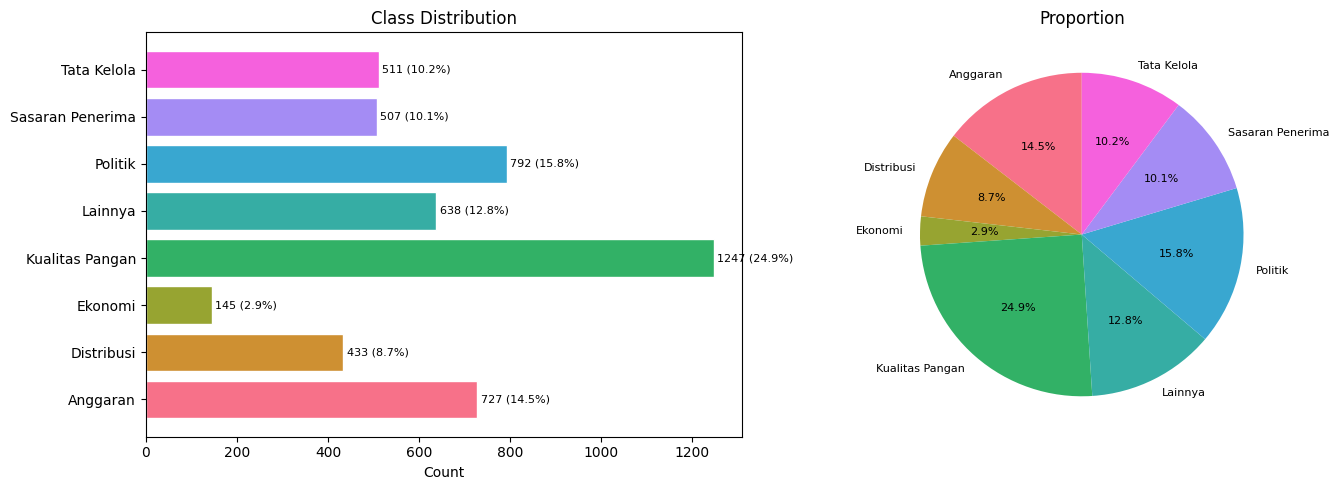

In [3]:
counts = labeled['label'].value_counts().reindex(LABEL_ORDER)
pct    = counts / counts.sum() * 100
colors = sns.color_palette('husl', len(LABEL_ORDER))

print('Class distribution:')
for lbl, cnt in counts.items():
    bar = '█' * int(cnt / 20)
    print(f'  {lbl:<22} {cnt:>5}  ({pct[lbl]:.1f}%)  {bar}')
print(f'\nImbalance ratio: {counts.max()/counts.min():.1f}x')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(counts.index, counts.values, color=colors, edgecolor='white')
axes[0].set_xlabel('Count'); axes[0].set_title('Class Distribution')
for i, (v, p) in enumerate(zip(counts.values, pct.values)):
    axes[0].text(v + 8, i, f'{v} ({p:.1f}%)', va='center', fontsize=8)
axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})
axes[1].set_title('Proportion')
plt.tight_layout(); plt.show()

## 1.2 Text Length

       char_len  word_len
count    5000.0    5000.0
mean      142.8      20.8
std        88.0      12.6
min         7.0       1.0
25%        73.0      11.0
50%       118.0      17.0
75%       209.0      31.0
max       966.0      68.0

Percentiles (char_len):
  p75: 209
  p90: 283
  p95: 300
  p99: 321


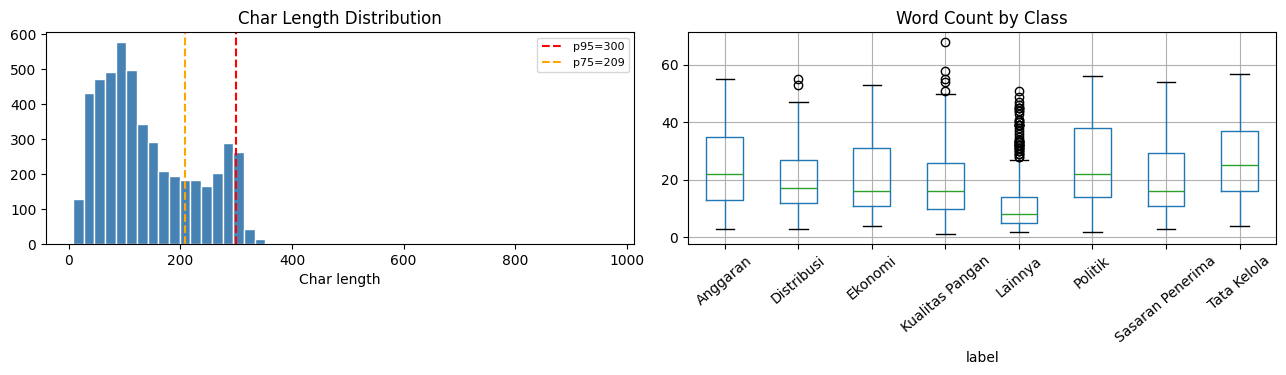

In [4]:
labeled['char_len'] = labeled['full_text'].str.len()
labeled['word_len'] = labeled['full_text'].str.split().str.len()

print(labeled[['char_len','word_len']].describe().round(1))
print('\nPercentiles (char_len):')
for p in [75, 90, 95, 99]:
    print(f'  p{p}: {np.percentile(labeled["char_len"], p):.0f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(labeled['char_len'], bins=50, color='steelblue', edgecolor='white')
for p, c in [(95,'red'),(75,'orange')]:
    v = np.percentile(labeled['char_len'], p)
    axes[0].axvline(v, color=c, linestyle='--', label=f'p{p}={v:.0f}')
axes[0].set_xlabel('Char length'); axes[0].set_title('Char Length Distribution')
axes[0].legend(fontsize=8)
labeled.boxplot(column='word_len', by='label', ax=axes[1], rot=40)
axes[1].set_title('Word Count by Class'); fig.suptitle('')
plt.tight_layout(); plt.show()

## 1.3 Special Token Prevalence

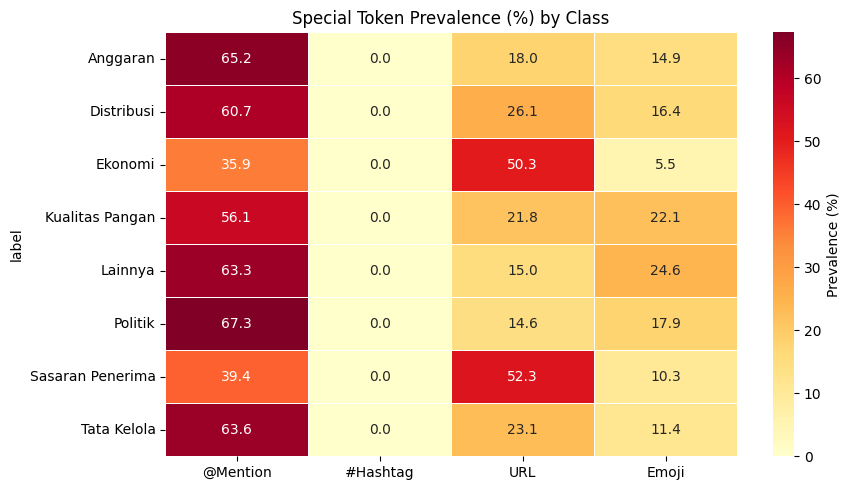

In [5]:
labeled['has_mention'] = labeled['full_text'].str.contains(r'@\w+', regex=True)
labeled['has_hashtag'] = labeled['full_text'].str.contains(r'#\w+', regex=True)
labeled['has_url']     = labeled['full_text'].str.contains(r'http\S+', regex=True)
labeled['has_emoji']   = labeled['full_text'].str.contains(r'[\U00010000-\U0010ffff]', regex=True)

agg = labeled.groupby('label')[['has_mention','has_hashtag','has_url','has_emoji']].mean().reindex(LABEL_ORDER) * 100
agg.columns = ['@Mention','#Hashtag','URL','Emoji']

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(agg, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label':'Prevalence (%)'})
ax.set_title('Special Token Prevalence (%) by Class')
plt.tight_layout(); plt.show()

## 1.4 Top Tokens per Class

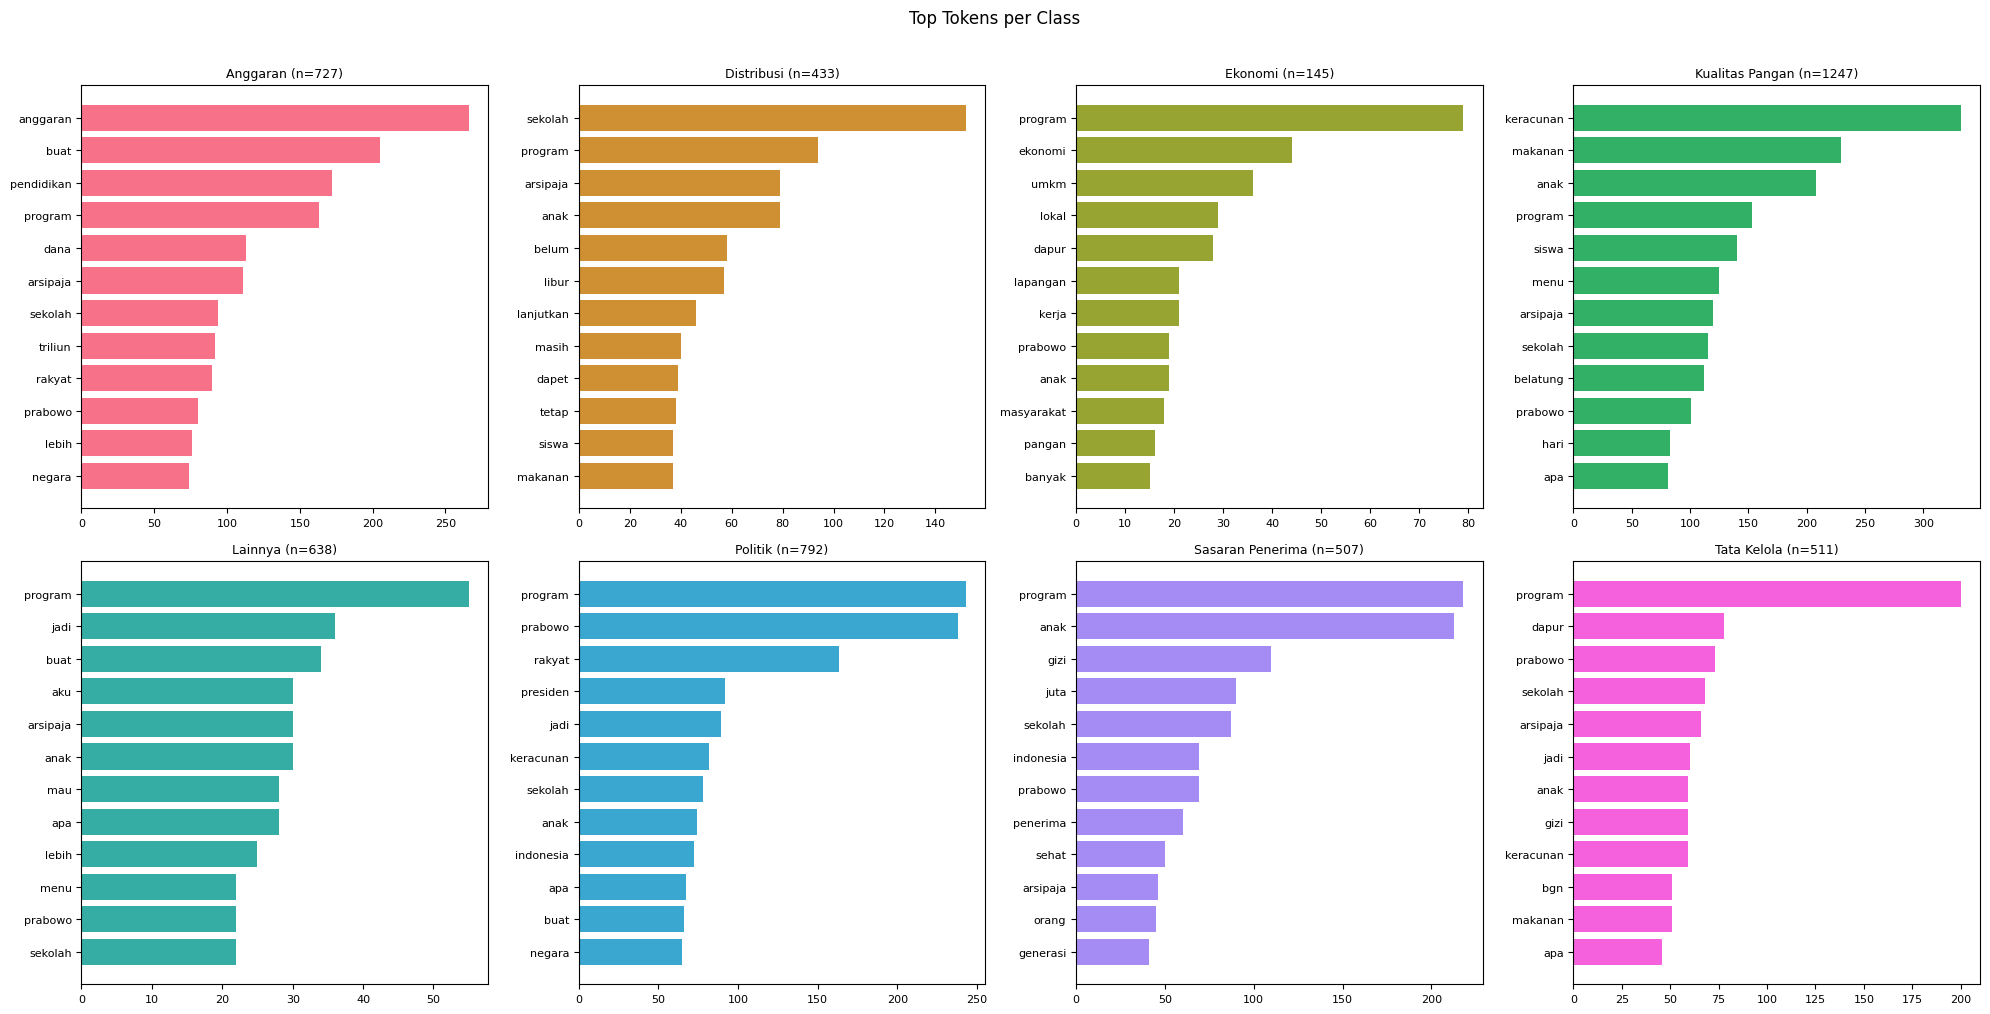

In [6]:
STOPWORDS = {
    'yang','di','dan','ini','itu','ke','dari','dengan','untuk','tidak',
    'ada','juga','mbg','makan','bergizi','gratis','ya','yg','gak','ga',
    'aja','sih','deh','lah','kalo','kalau','bisa','udah','sudah','akan',
    'nih','tapi','rt','amp','https','co','t','user','url','nya','kita',
}

def top_tokens(texts, n=12):
    tokens = []
    for t in texts:
        toks = re.findall(r'\b[a-zA-Z]{3,}\b', str(t).lower())
        tokens.extend([w for w in toks if w not in STOPWORDS])
    return Counter(tokens).most_common(n)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for idx, lbl in enumerate(LABEL_ORDER):
    subset = labeled[labeled['label'] == lbl]['full_text']
    top = top_tokens(subset)
    if not top: continue
    words, freqs = zip(*top)
    axes[idx].barh(words[::-1], freqs[::-1], color=colors[idx])
    axes[idx].set_title(f'{lbl} (n={len(subset)})', fontsize=9)
    axes[idx].tick_params(labelsize=8)
plt.suptitle('Top Tokens per Class', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

## 1.5 Label Distribution Comparison (Original vs LLM-labeled)

                  Original  LLM Labeled  Delta
label                                         
Anggaran               727          767     40
Distribusi             433          368    -65
Ekonomi                145          196     51
Kualitas Pangan       1247         1229    -18
Lainnya                638          570    -68
Politik                792          780    -12
Sasaran Penerima       507          521     14
Tata Kelola            511          569     58


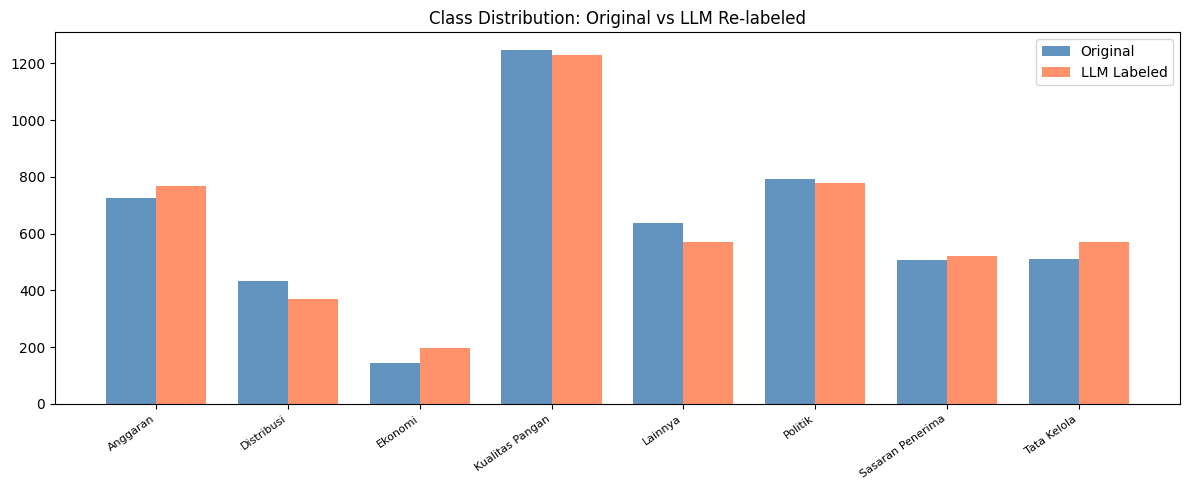

In [7]:
try:
    new_labeled = pd.read_excel(DATA_DIR / 'labeled/hasil_label_baru.xlsx')
    new_labeled.columns = [c.strip().lower() for c in new_labeled.columns]
    new_labeled['label'] = new_labeled['label'].astype(str).str.strip()

    orig_counts = labeled['label'].value_counts().reindex(LABEL_ORDER, fill_value=0)
    new_counts  = new_labeled['label'].value_counts().reindex(LABEL_ORDER, fill_value=0)

    comp = pd.DataFrame({'Original': orig_counts, 'LLM Labeled': new_counts})
    comp['Delta'] = comp['LLM Labeled'] - comp['Original']
    print(comp.to_string())

    fig, ax = plt.subplots(figsize=(12, 5))
    x = range(len(LABEL_ORDER))
    w = 0.38
    ax.bar([i-w/2 for i in x], orig_counts, w, label='Original', color='steelblue', alpha=0.85)
    ax.bar([i+w/2 for i in x], new_counts,  w, label='LLM Labeled', color='coral', alpha=0.85)
    ax.set_xticks(list(x)); ax.set_xticklabels(LABEL_ORDER, rotation=35, ha='right', fontsize=8)
    ax.set_title('Class Distribution: Original vs LLM Re-labeled')
    ax.legend(); plt.tight_layout(); plt.show()
except FileNotFoundError:
    print('hasil_label_baru.xlsx not found in data/labeled/ — skip comparison')